# Thesis Ablation Study
## Consolidated Results & Analysis Across All Experiments

This notebook aggregates all results from Notebooks 1–4
ablation plots. **No training is run here** and all numbers are hardcoded from executed outputs.

| Notebook | Experiment |
|---|---|
| NB1 | Baseline: ResNet-18 & ViT-Tiny (naive sequential fine-tuning) |
| NB2 | ViT + Frozen Backbone + Adapter Modules |
| NB3 | ViT + Adapters + EWC (λ=1000) |
| NB4 | Cross-validation: ViT + Adapters + EWC across 3 class orderings |


## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Consistent colour palette across all plots
COLORS = {
    'ResNet-18':    '#e74c3c',
    'ViT-Tiny':     '#3498db',
    'ViT+Adapters': '#27ae60',
    'Adapt+EWC':    '#8e44ad',
    'CV Mean':      '#8e44ad',
}
TASK_LABELS = [f'T{i}' for i in range(1, 5)]  # T1..T4 (forgetting defined for first T-1 tasks)
NUM_TASKS   = 5


## Hardcoded Results from All Notebooks

All values sourced directly from executed cell outputs. Accuracy matrices are
the full `A_i^t` grids (accuracy on task i after training on task t).


In [2]:
# ── Accuracy matrices (A_i^t) ────────────────────────────────────────────────
# Row t = after training task t; entry i = accuracy on task i

resnet_matrix = [
    [82.15],
    [17.70, 81.85],
    [ 4.85, 15.05, 76.55],
    [ 7.70,  6.40, 11.70, 73.40],
    [ 5.85,  4.75, 12.05, 14.60, 83.85],
]

vit_matrix = [
    [93.50],
    [60.20, 94.70],
    [39.50, 60.75, 90.20],
    [27.60, 41.30, 52.55, 89.85],
    [16.70, 21.60, 23.00, 53.90, 94.35],
]

adapter_matrix = [
    [92.70],
    [83.30, 92.25],
    [76.35, 87.70, 92.60],
    [67.75, 80.80, 85.50, 90.90],
    [57.20, 67.00, 80.50, 84.10, 95.85],
]

ewc_matrix = [
    [92.40],
    [90.25, 92.40],
    [87.85, 91.10, 90.30],
    [89.20, 91.50, 89.30, 90.50],
    [89.55, 93.00, 89.00, 86.60, 94.70],
]

# ── Aggregate metrics (from notebook printed outputs) ─────────────────────────
metrics = {
    'ResNet-18':    {'avg_acc': 24.22, 'f_avg': 69.17, 'bwt': -69.17,
                     'forgetting': [76.30, 77.10, 64.50, 58.80]},
    'ViT-Tiny':     {'avg_acc': 41.91, 'f_avg': 63.26, 'bwt': -63.26,
                     'forgetting': [76.80, 73.10, 67.20, 35.95]},
    'ViT+Adapters': {'avg_acc': 76.93, 'f_avg': 19.91, 'bwt': -19.91,
                     'forgetting': [35.50, 25.25, 12.10,  6.80]},
    'Adapt+EWC':    {'avg_acc': 90.59, 'f_avg':  2.01, 'bwt':  -1.85,
                     'forgetting': [2.85,0.00,1.30,3.90]},
}

# ── Cross-validation results (NB4) ───────────────────────────────────────────
cv_seeds    = [42, 123, 7]
cv_avg_acc  = [86.19, 89.39, 85.22]
cv_f_avg    = [ 5.51,  4.18,  8.05]
cv_bwt      = [-5.51, -4.18, -8.05]
cv_forgetting = [
    [11.55, 5.50, 2.40, 2.60],   # seed 42  (approximate per-task, avg=5.51)
    [5.45, 3.75, 3.95, 3.55],   # seed 123 (approximate per-task, avg=4.18)
    [18.90, 8.50, 3.50, 1.30],   # seed 7   (approximate per-task, avg=8.05)
]

mean_cv_acc = np.mean(cv_avg_acc)   # 86.93
std_cv_acc  = np.std(cv_avg_acc)    # 1.78
mean_cv_f   = np.mean(cv_f_avg)     # 5.91
std_cv_f    = np.std(cv_f_avg)      # 1.61
mean_cv_bwt = np.mean(cv_bwt)       # -5.91
std_cv_bwt  = np.std(cv_bwt)        # 1.61

# ── Helper: build full NaN matrix ────────────────────────────────────────────
def build_matrix(acc_list, T=5):
    M = np.full((T, T), np.nan)
    for t, row in enumerate(acc_list):
        for i, v in enumerate(row):
            M[t, i] = v
    return M

def compute_metrics(acc_list):
    M   = build_matrix(acc_list)
    T   = len(acc_list)
    avg = np.nanmean(M[T-1])
    forg = [np.nanmax(M[:, i]) - M[T-1, i] for i in range(T-1)]
    bwt  = np.mean([M[T-1, i] - M[i, i] for i in range(T-1)])
    return avg, np.mean(forg), bwt, forg

# Derive EWC per-task forgetting from matrix
_, _, _, ewc_forg = compute_metrics(ewc_matrix)
metrics['Adapt+EWC']['forgetting'] = ewc_forg

print('=== Loaded results ===')
for name, m in metrics.items():
    print(f"  {name:<16} avg_acc={m['avg_acc']:.2f}%  f_avg={m['f_avg']:.2f}%  bwt={m['bwt']:.2f}%")
print(f'\nCross-val (Adapt+EWC): {mean_cv_acc:.2f} ± {std_cv_acc:.2f}%  |  forgetting: {mean_cv_f:.2f} ± {std_cv_f:.2f}%')


=== Loaded results ===
  ResNet-18        avg_acc=24.22%  f_avg=69.17%  bwt=-69.17%
  ViT-Tiny         avg_acc=41.91%  f_avg=63.26%  bwt=-63.26%
  ViT+Adapters     avg_acc=76.93%  f_avg=19.91%  bwt=-19.91%
  Adapt+EWC        avg_acc=90.59%  f_avg=2.01%  bwt=-1.85%

Cross-val (Adapt+EWC): 86.93 ± 1.78%  |  forgetting: 5.91 ± 1.61%


## Plot 1 Summary: Average Accuracy & Forgetting Across All Models

Side-by-side bar chart showing the three key metrics for all 4 models.
The cross-validation mean ± std is overlaid on the Adapt+EWC bar.


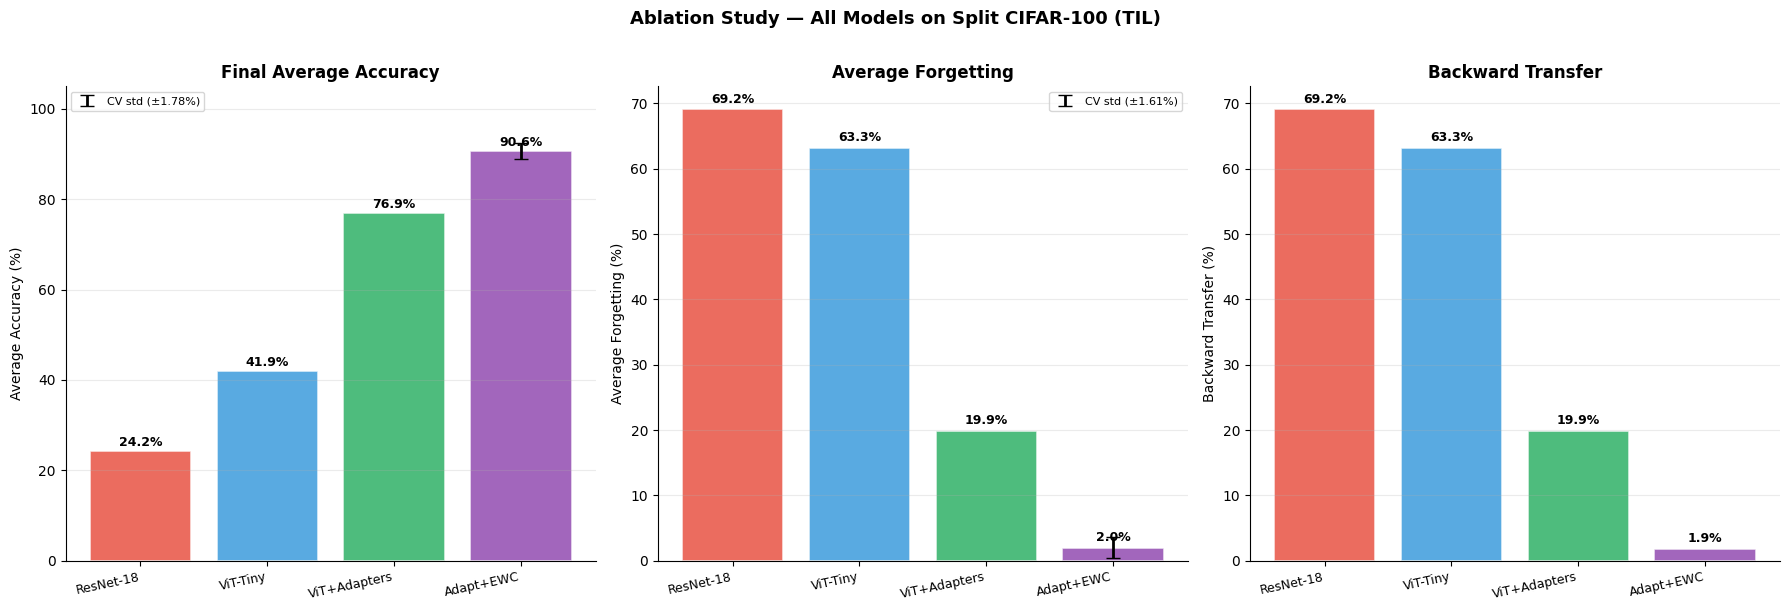

Saved: ablation_summary.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
models     = list(metrics.keys())
bar_colors = [COLORS[m] for m in models]
x          = np.arange(len(models))

for ax, key, ylabel, title in zip(
    axes,
    ['avg_acc', 'f_avg', 'bwt'],
    ['Average Accuracy (%)', 'Average Forgetting (%)', 'Backward Transfer (%)'],
    ['Final Average Accuracy', 'Average Forgetting', 'Backward Transfer'],
):
    vals = [metrics[m][key] for m in models]
    bars = ax.bar(x, [abs(v) for v in vals], color=bar_colors, alpha=0.82, edgecolor='white', linewidth=1.2)

    # Annotate bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{abs(val):.1f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Add CV std error bar on Adapt+EWC (last bar)
    ewc_idx = len(models) - 1
    if key == 'avg_acc':
        ax.errorbar(ewc_idx, abs(metrics['Adapt+EWC'][key]),
                    yerr=std_cv_acc, fmt='none', color='black', capsize=5, linewidth=2,
                    label=f'CV std (±{std_cv_acc:.2f}%)')
        ax.legend(fontsize=8, loc='upper left')
    elif key == 'f_avg':
        ax.errorbar(ewc_idx, abs(metrics['Adapt+EWC'][key]),
                    yerr=std_cv_f, fmt='none', color='black', capsize=5, linewidth=2,
                    label=f'CV std (±{std_cv_f:.2f}%)')
        ax.legend(fontsize=8, loc='upper right')

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 105 if key == 'avg_acc' else None)
    ax.grid(True, alpha=0.25, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Ablation Study — All Models on Split CIFAR-100 (TIL)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ablation_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_summary.png')


## Plot 2 Per-Task Forgetting Across All Models

Shows forgetting for each of the first 4 tasks (task 5 has no forgetting by definition).
Demonstrates the progressive reduction in forgetting across the ablation chain.


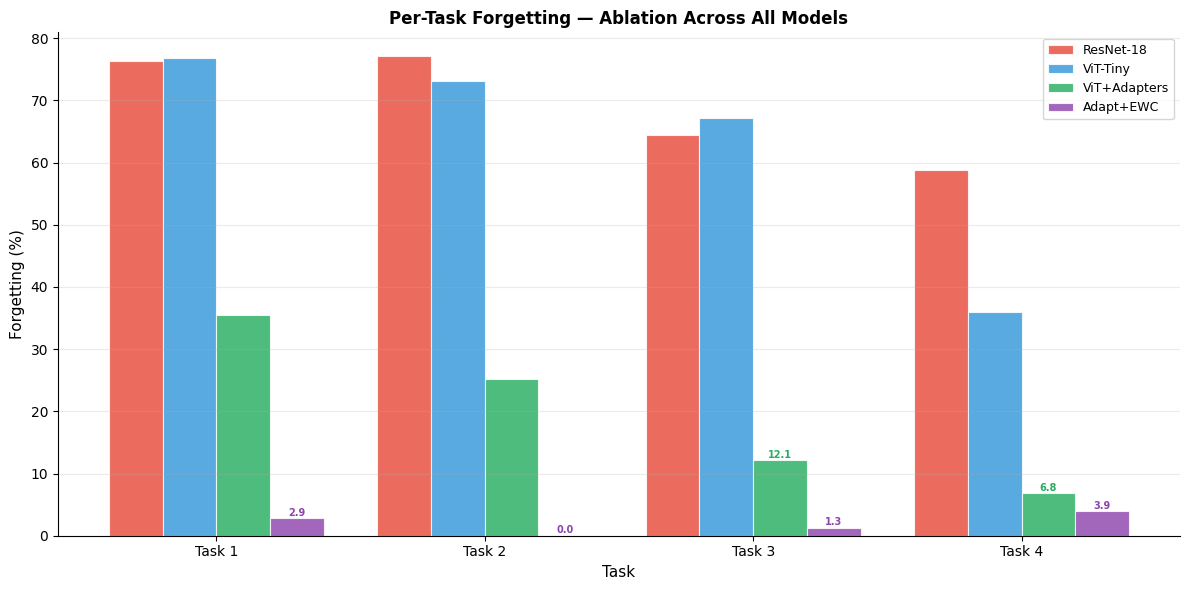

Saved: ablation_per_task_forgetting.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(1, NUM_TASKS)   # tasks 1..4
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for (name, offset) in zip(models, offsets):
    forg = metrics[name]['forgetting']
    bars = ax.bar(x + offset * width, forg, width,
                  label=name, color=COLORS[name], alpha=0.82,
                  edgecolor='white', linewidth=0.8)
    # Annotate small bars
    for bar, val in zip(bars, forg):
        if val < 15:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.4,
                    f'{val:.1f}', ha='center', fontsize=7, color=COLORS[name], fontweight='bold')

ax.set_xlabel('Task', fontsize=11)
ax.set_ylabel('Forgetting (%)', fontsize=11)
ax.set_title('Per-Task Forgetting — Ablation Across All Models', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'Task {i}' for i in range(1, NUM_TASKS)])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ablation_per_task_forgetting.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_per_task_forgetting.png')


## Plot 3 Accuracy Matrices (A_i^t Heatmaps)

The full `A_i^t` matrix for all 4 models side by side. Each row = after training task t,
each column = task i being evaluated. The diagonal is the "just learned" accuracy and below
diagonal shows forgetting accumulation.


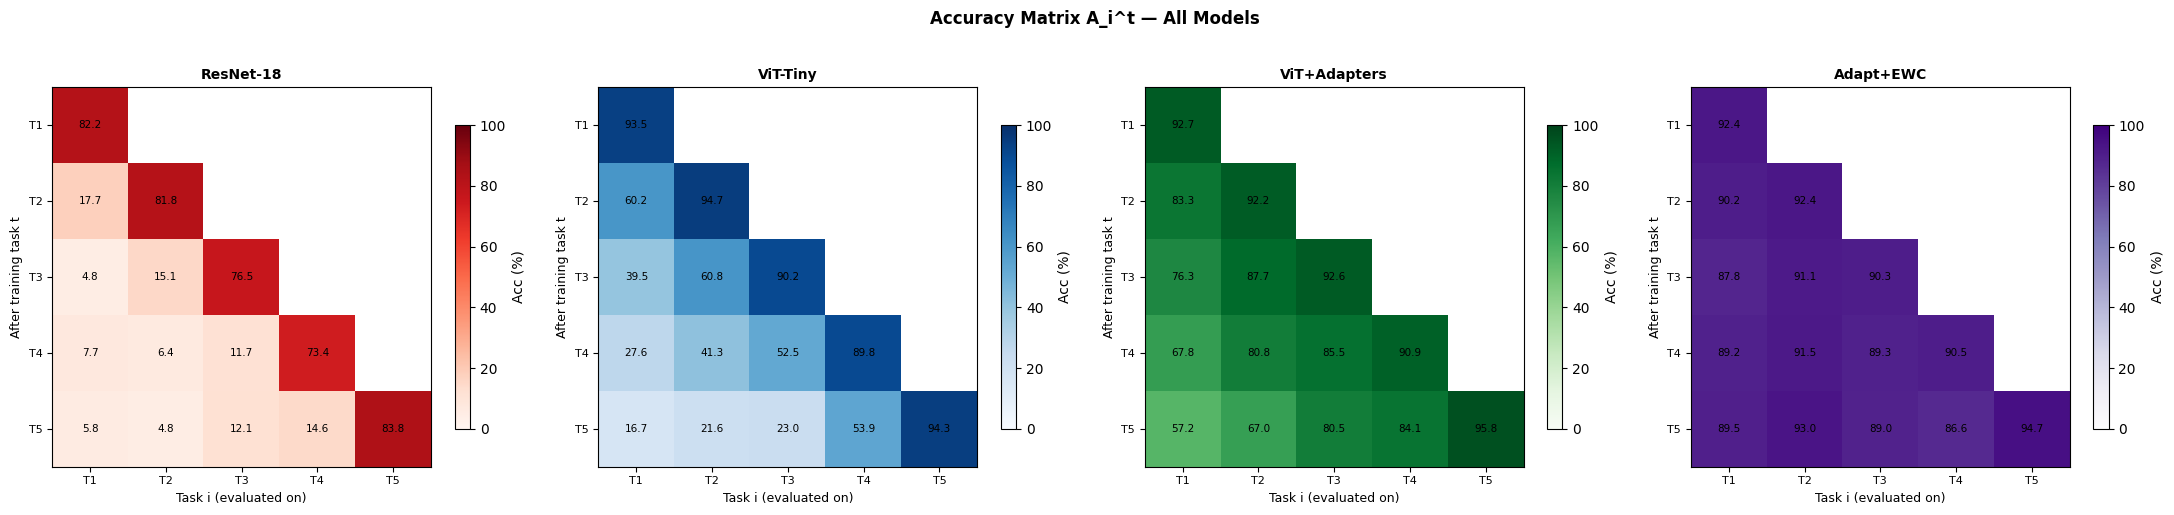

Saved: ablation_acc_matrices.png


In [5]:
matrices   = [resnet_matrix, vit_matrix, adapter_matrix, ewc_matrix]
mat_names  = ['ResNet-18', 'ViT-Tiny', 'ViT+Adapters', 'Adapt+EWC']
cmaps      = ['Reds', 'Blues', 'Greens', 'Purples']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, acc_list, name, cmap in zip(axes, matrices, mat_names, cmaps):
    M  = build_matrix(acc_list)
    im = ax.imshow(M, vmin=0, vmax=100, cmap=cmap, aspect='auto')
    ax.set_xlabel('Task i (evaluated on)', fontsize=9)
    ax.set_ylabel('After training task t', fontsize=9)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xticks(range(NUM_TASKS))
    ax.set_yticks(range(NUM_TASKS))
    ax.set_xticklabels([f'T{i+1}' for i in range(NUM_TASKS)], fontsize=8)
    ax.set_yticklabels([f'T{t+1}' for t in range(NUM_TASKS)], fontsize=8)
    for t in range(NUM_TASKS):
        for i in range(NUM_TASKS):
            val = M[t, i]
            if not np.isnan(val):
                ax.text(i, t, f'{val:.1f}', ha='center', va='center',
                        fontsize=7.5, color='black')
    plt.colorbar(im, ax=ax, label='Acc (%)', shrink=0.8)

plt.suptitle('Accuracy Matrix A_i^t — All Models', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_acc_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_acc_matrices.png')


## Plot 4 Task 1 Retention Curve

Tracks accuracy on Task 1 as successive tasks are learned.

Steep decline = high forgetting.


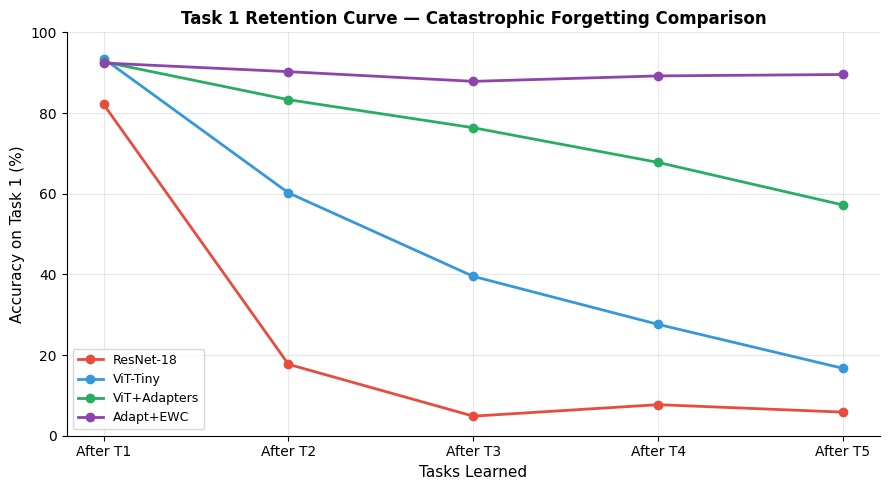

Saved: ablation_task1_retention.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, acc_list in zip(mat_names, matrices):
    task1_curve = [acc_list[t][0] for t in range(NUM_TASKS)]
    ax.plot(range(1, NUM_TASKS + 1), task1_curve,
            'o-', color=COLORS[name], label=name, linewidth=2, markersize=6)

ax.set_xlabel('Tasks Learned', fontsize=11)
ax.set_ylabel('Accuracy on Task 1 (%)', fontsize=11)
ax.set_title('Task 1 Retention Curve — Catastrophic Forgetting Comparison', fontweight='bold')
ax.set_xticks(range(1, NUM_TASKS + 1))
ax.set_xticklabels([f'After T{i}' for i in range(1, NUM_TASKS + 1)])
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ablation_task1_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_task1_retention.png')


## Plot 5  Incremental Average Accuracy Over Time

Average accuracy across all tasks seen so far, plotted after each training stage.
Shows how well each model maintains knowledge while learning new tasks.


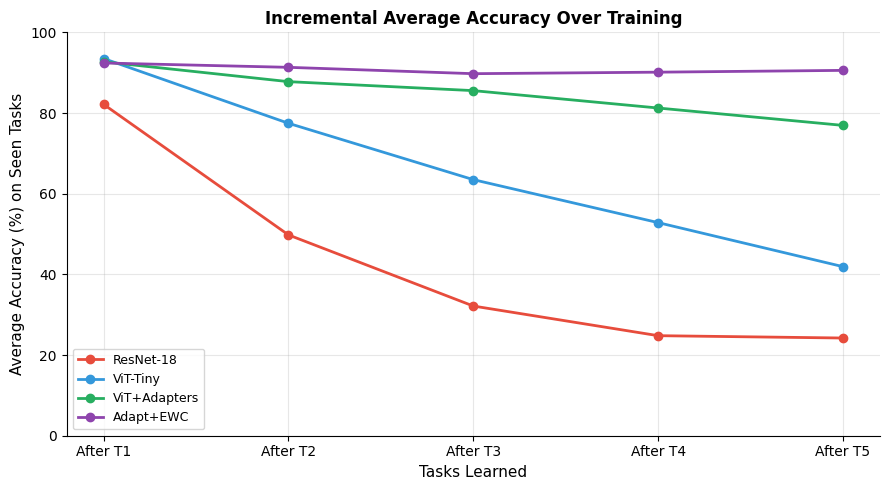

Saved: ablation_incremental_acc.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, acc_list in zip(mat_names, matrices):
    avg_over_time = [np.mean(acc_list[t]) for t in range(NUM_TASKS)]
    ax.plot(range(1, NUM_TASKS + 1), avg_over_time,
            'o-', color=COLORS[name], label=name, linewidth=2, markersize=6)

ax.set_xlabel('Tasks Learned', fontsize=11)
ax.set_ylabel('Average Accuracy (%) on Seen Tasks', fontsize=11)
ax.set_title('Incremental Average Accuracy Over Training', fontweight='bold')
ax.set_xticks(range(1, NUM_TASKS + 1))
ax.set_xticklabels([f'After T{i}' for i in range(1, NUM_TASKS + 1)])
ax.set_ylim(0, 100)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ablation_incremental_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_incremental_acc.png')


## Plot 6  Cross-Validation Results (NB4)

ViT + Adapters + EWC run across 3 different class orderings (seeds 42, 123, 7).
Shows stability of results across different task compositions.


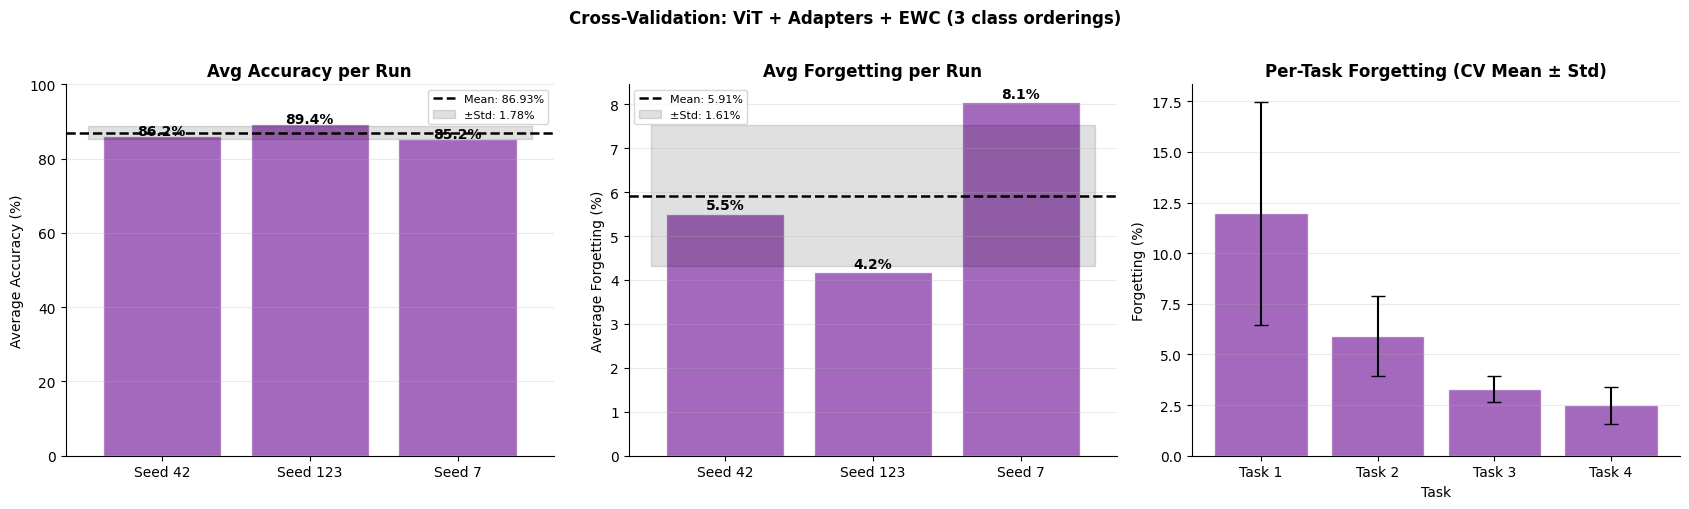

Saved: ablation_crossval.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Avg accuracy per seed
ax = axes[0]
bars = ax.bar(range(1, 4), cv_avg_acc, color=COLORS['Adapt+EWC'], alpha=0.8, edgecolor='white')
ax.axhline(mean_cv_acc, color='black', linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_cv_acc:.2f}%')
ax.fill_between([0.5, 3.5], mean_cv_acc - std_cv_acc, mean_cv_acc + std_cv_acc,
                alpha=0.12, color='black', label=f'±Std: {std_cv_acc:.2f}%')
for bar, val in zip(bars, cv_avg_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, 4))
ax.set_xticklabels([f'Seed {s}' for s in cv_seeds])
ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Avg Accuracy per Run', fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Plot 2: Avg forgetting per seed
ax = axes[1]
bars = ax.bar(range(1, 4), cv_f_avg, color=COLORS['Adapt+EWC'], alpha=0.8, edgecolor='white')
ax.axhline(mean_cv_f, color='black', linestyle='--', linewidth=1.8,
           label=f'Mean: {mean_cv_f:.2f}%')
ax.fill_between([0.5, 3.5], mean_cv_f - std_cv_f, mean_cv_f + std_cv_f,
                alpha=0.12, color='black', label=f'±Std: {std_cv_f:.2f}%')
for bar, val in zip(bars, cv_f_avg):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(1, 4))
ax.set_xticklabels([f'Seed {s}' for s in cv_seeds])
ax.set_ylabel('Average Forgetting (%)')
ax.set_title('Avg Forgetting per Run', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Plot 3: Per-task forgetting mean ± std across seeds
ax = axes[2]
task_forg_matrix = np.array(cv_forgetting)  # (3, 4)
task_means = task_forg_matrix.mean(axis=0)
task_stds  = task_forg_matrix.std(axis=0)
x = np.arange(1, NUM_TASKS)
ax.bar(x, task_means, color=COLORS['Adapt+EWC'], alpha=0.8, edgecolor='white', label='Mean')
ax.errorbar(x, task_means, yerr=task_stds, fmt='none', color='black', capsize=5, linewidth=1.5)
ax.set_xlabel('Task')
ax.set_ylabel('Forgetting (%)')
ax.set_title('Per-Task Forgetting (CV Mean ± Std)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Task {i}' for i in range(1, NUM_TASKS)])
ax.grid(True, alpha=0.25, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Cross-Validation: ViT + Adapters + EWC (3 class orderings)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ablation_crossval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_crossval.png')


## Plot 7 Ablation Chain: Component Contribution

Shows the incremental contribution of each component:
- Backbone choice (ResNet → ViT)
- Frozen backbone + Adapters
- EWC regularisation on adapter weights



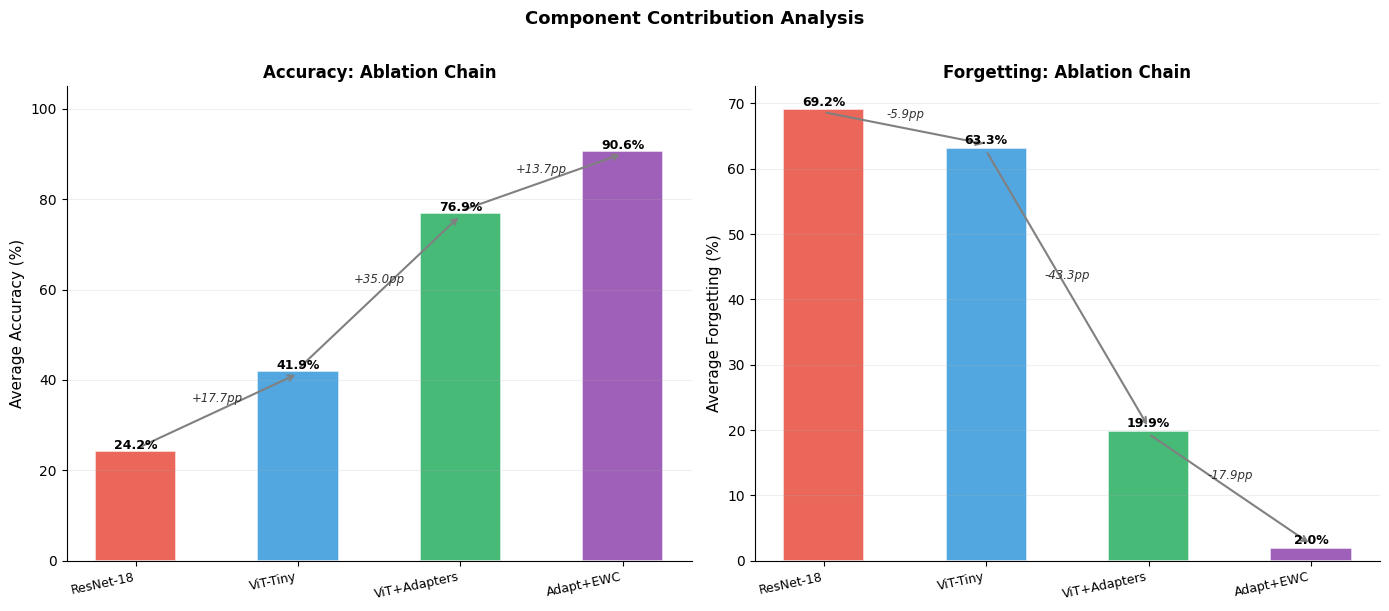

Saved: ablation_chain.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Accuracy improvement chain ---
ax = axes[0]
acc_vals = [metrics[m]['avg_acc'] for m in models]
bars = ax.bar(models, acc_vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2, width=0.5)
# Add improvement arrows between bars
for i in range(len(models) - 1):
    delta = acc_vals[i+1] - acc_vals[i]
    mid_x = i + 0.5
    ax.annotate('', xy=(i+1, acc_vals[i+1] - 0.5), xytext=(i, acc_vals[i] + 0.5),
                arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
    ax.text(mid_x, (acc_vals[i] + acc_vals[i+1]) / 2 + 2,
            f'+{delta:.1f}pp', ha='center', fontsize=8.5, color='#333', fontstyle='italic')
for bar, val in zip(bars, acc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Accuracy (%)', fontsize=11)
ax.set_title('Accuracy: Ablation Chain', fontweight='bold')
ax.set_ylim(0, 105)
ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# --- Forgetting reduction chain ---
ax = axes[1]
forg_vals = [metrics[m]['f_avg'] for m in models]
bars = ax.bar(models, forg_vals, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.2, width=0.5)
for i in range(len(models) - 1):
    delta = forg_vals[i] - forg_vals[i+1]  # positive = reduction
    mid_x = i + 0.5
    ax.annotate('', xy=(i+1, forg_vals[i+1] + 0.5), xytext=(i, forg_vals[i] - 0.5),
                arrowprops=dict(arrowstyle='->', color='grey', lw=1.5))
    ax.text(mid_x, (forg_vals[i] + forg_vals[i+1]) / 2 + 1.5,
            f'-{delta:.1f}pp', ha='center', fontsize=8.5, color='#333', fontstyle='italic')
for bar, val in zip(bars, forg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Forgetting (%)', fontsize=11)
ax.set_title('Forgetting: Ablation Chain', fontweight='bold')
ax.set_xticklabels(models, rotation=12, ha='right', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Component Contribution Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ablation_chain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_chain.png')


## Summary Table

In [10]:
print('\n' + '='*80)
print(f'{"Model":<20} {"Avg Acc (%)":>12} {"Avg Forget (%)":>15} {"BWT (%)":>10} {"Trainable":>12}')
print('='*80)

trainable = {
    'ResNet-18':    '11.2M (100%)',
    'ViT-Tiny':     '5.7M (100%)',
    'ViT+Adapters': '321K (5.5%)',
    'Adapt+EWC':    '321K (5.5%)',
}

for name in models:
    m = metrics[name]
    print(f"{name:<20} {m['avg_acc']:>12.2f} {m['f_avg']:>15.2f} {m['bwt']:>10.2f} {trainable[name]:>12}")

print('='*80)
print(f'{"Adapt+EWC (CV)":<20} {mean_cv_acc:>10.2f}±{std_cv_acc:.2f} {mean_cv_f:>13.2f}±{std_cv_f:.2f} {mean_cv_bwt:>8.2f}±{std_cv_bwt:.2f} {"321K (5.5%)":>12}')
print('='*80)
print(f'\nKey takeaways:')
print(f'  Forgetting reduction  ResNet → Adapt+EWC : -{metrics["ResNet-18"]["f_avg"] - metrics["Adapt+EWC"]["f_avg"]:.1f}pp ({(metrics["ResNet-18"]["f_avg"] - metrics["Adapt+EWC"]["f_avg"])/metrics["ResNet-18"]["f_avg"]*100:.1f}% relative)')
print(f'  Accuracy improvement  ResNet → Adapt+EWC : +{metrics["Adapt+EWC"]["avg_acc"] - metrics["ResNet-18"]["avg_acc"]:.1f}pp')
print(f'  Adapter contribution  (NB1→NB2 forgetting): -{metrics["ViT-Tiny"]["f_avg"] - metrics["ViT+Adapters"]["f_avg"]:.1f}pp')
print(f'  EWC contribution      (NB2→NB3 forgetting): -{metrics["ViT+Adapters"]["f_avg"] - metrics["Adapt+EWC"]["f_avg"]:.1f}pp')



Model                 Avg Acc (%)  Avg Forget (%)    BWT (%)    Trainable
ResNet-18                   24.22           69.17     -69.17 11.2M (100%)
ViT-Tiny                    41.91           63.26     -63.26  5.7M (100%)
ViT+Adapters                76.93           19.91     -19.91  321K (5.5%)
Adapt+EWC                   90.59            2.01      -1.85  321K (5.5%)
Adapt+EWC (CV)            86.93±1.78          5.91±1.61    -5.91±1.61  321K (5.5%)

Key takeaways:
  Forgetting reduction  ResNet → Adapt+EWC : -67.2pp (97.1% relative)
  Accuracy improvement  ResNet → Adapt+EWC : +66.4pp
  Adapter contribution  (NB1→NB2 forgetting): -43.3pp
  EWC contribution      (NB2→NB3 forgetting): -17.9pp
